In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [2]:
class quadstate(TypedDict):
    a: int
    b:int
    c:int
    

In [3]:
graph=StateGraph(quadstate)

In [4]:
def show_equetion(state:quadstate):
    equetion=f' {state['a']}x2{state['b']}x{state['c']} '
    return {'equetion':equetion}

def calculte_dicrimint(state:quadstate):
    discrimint=state['b']**2-(4*state['a']*state['c'])
    return {'discrimint':discrimint}

In [5]:
# add node
graph.add_node('show_equetion',show_equetion)
graph.add_node('calculte_dicrimint',calculte_dicrimint)
# add edege
graph.add_edge(START,'show_equetion')
graph.add_edge('show_equetion','calculte_dicrimint')
graph.add_edge('calculte_dicrimint',END)
workflow=graph.compile()

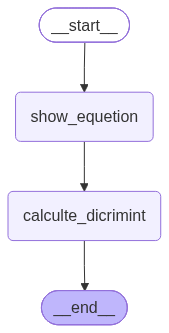

In [7]:
workflow

In [10]:
inatial={
    'a':2,
    'b':3,
    'c':6
    
}

In [11]:
workflow.invoke(inatial)

{'a': 2, 'b': 3, 'c': 6}

# llm conditional

In [49]:
from langgraph.graph import START,StateGraph,END
from langchain_ollama import ChatOllama
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field

In [50]:
model=ChatOllama(model='smollm:135m')


In [51]:
class sentimateschema(BaseModel):
    sentiment :Literal['positve','negative']=Field(description='sentiment of the review')
    

In [52]:
class daignosisschema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')
    

In [54]:
sentiment_model=model.with_structured_output(sentimateschema)
setiment_model1=model.with_structured_output(daignosisschema)

In [55]:
prompt='what is the sentiment of following review- the software is bad'
sentiment_model.invoke(prompt)

sentimateschema(sentiment='negative')

In [82]:
class reviewstate(TypedDict):
    review:str
    sentiment:str
    dignosis:dict
    response:str

    

In [115]:
graph=StateGraph(reviewstate)
def find_sentiment(state:reviewstate):
    prompt=f' for the foloowing  review find out the sentiment \n {state['review']} '
    
    sentiment=sentiment_model.invoke(prompt)
    return {'sentiment':sentiment}

def chek_sentiment(state:reviewstate)-> Literal['positive_response','run_diagnosis']:
    if state['sentiment']=='positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state:reviewstate):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    

    response=model.invoke(prompt)
    return {'response':response}
def run_diagnosis(state: reviewstate):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = setiment_model1.invoke(prompt)

    return {'diagnosis': response.model_dump()}


def negative_response(state: reviewstate):
    dignosis = state['dignosis']
    
    promt = f"""
You are a supporting assistant. 
The user had a '{dignosis['issue_type']}' issue, sounded '{dignosis['tone']}', and marked urgency as '{dignosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(promt).content
    return {'response': response}

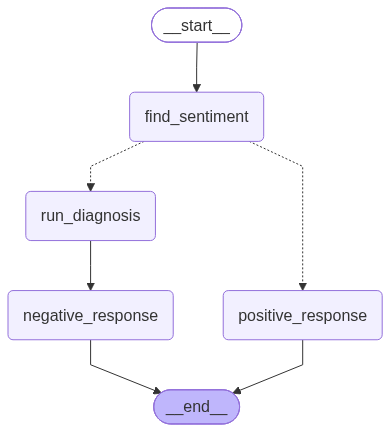

In [116]:
# add nodes
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)
graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',chek_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)
workflow=graph.compile()
workflow

In [118]:
user={
    'review':' the product is good'
}

res=workflow.invoke(user)